H:\Data Minning\BTL2\venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({CustomerID}),frozenset({Quantity}),1.000000,0.978111,0.978111,0.978111,1.0,1.0,0.0,1.0,0.0,0.978111,0.0,0.989056
1,frozenset({Quantity}),frozenset({CustomerID}),0.978111,1.000000,0.978111,1.000000,1.0,1.0,0.0,inf,0.0,0.978111,0.0,0.989056
2,frozenset({UnitPrice}),frozenset({CustomerID}),0.999902,1.000000,0.999902,1.000000,1.0,1.0,0.0,inf,0.0,0.999902,0.0,0.999951
3,frozenset({CustomerID}),frozenset({UnitPrice}),1.000000,0.999902,0.999902,0.999902,1.0,1.0,0.0,1.0,0.0,0.999902,0.0,0.999951
4,"frozenset({UnitPrice, Quantity})",frozenset({CustomerID}),0.978013,1.000000,0.978013,1.000000,1.0,1.0,0.0,inf,0.0,0.978013,0.0,0.989006
5,frozenset({CustomerID}),"frozenset({UnitPrice, Quantity})",1.000000,0.978013,0.978013,0.978013,1.0,1.0,0.0,1.0,0.0,0.978013,0.0,0.989006


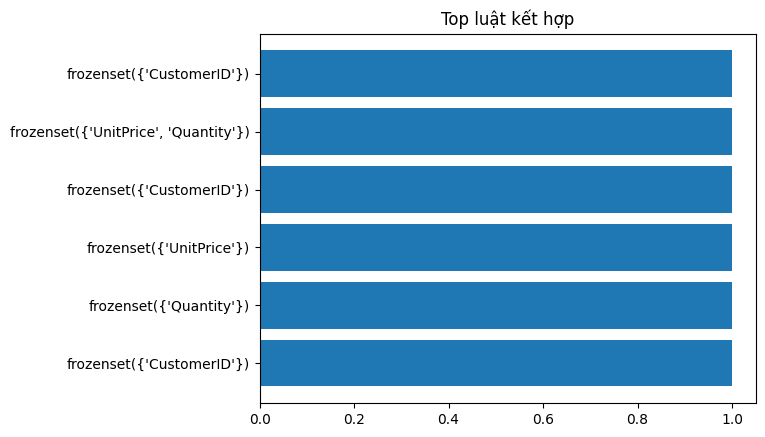

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from mlxtend.frequent_patterns import apriori, association_rules

# =====================
# 1. ĐỌC DỮ LIỆU
# =====================
df = pd.read_csv("../outputs/cleaned_data.csv")

# =====================
# 2. CHUYỂN DỮ LIỆU SANG DẠNG NHỊ PHÂN
# =====================
df_bin = df.select_dtypes(include=['int64','float64']) > 0

# =====================
# 3. TÌM FREQUENT ITEMSETS
# =====================
frequent = apriori(df_bin, min_support=0.05, use_colnames=True)

# =====================
# 4. SINH LUẬT
# =====================
rules = association_rules(frequent, metric="lift", min_threshold=1)

rules = rules.sort_values(by="lift", ascending=False)

display(rules.head(10))

# Lưu file
rules.to_csv("../outputs/rules.csv", index=False)

# =====================
# 5. TRỰC QUAN
# =====================
top_rules = rules.head(10)

plt.figure()
plt.barh(range(len(top_rules)), top_rules['lift'])
plt.yticks(range(len(top_rules)), top_rules['antecedents'].astype(str))
plt.title("Top luật kết hợp")
plt.savefig("../outputs/top_rules.png")
plt.show()